<a href="https://colab.research.google.com/github/manel-gr/real-estate-price-prediction/blob/main/Pr%C3%A9diction_des_Prix_Immobiliers.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import RobustScaler
from google.colab import drive
drive.mount('/content/drive')
import os

os.listdir('/content/drive/MyDrive/dataset_Immobiliers')
df_21 = pd.read_csv(
    '/content/drive/MyDrive/dataset_Immobiliers/full_2021.csv',
    low_memory=False,
    encoding='latin-1'
)

df_22 = pd.read_csv(
    '/content/drive/MyDrive/dataset_Immobiliers/full_2022.csv',
    low_memory=False,
    encoding='latin-1'
)

df_23 = pd.read_csv(
    '/content/drive/MyDrive/dataset_Immobiliers/full_2023.csv',
    low_memory=False,
    encoding='latin-1'
)



Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
df_21["annee"]=2021
df_22["annee"]=2022
df_23["annee"]=2023
df=pd.concat([df_21,df_22,df_23],ignore_index=True)
df = df.sample(n=100000, random_state=42)
print(df.info())
print(df.head())
print('description prix')
print("prix moyenne :",round(df["valeur_fonciere"].mean(),2))
print("prix médiane :",df["valeur_fonciere"].median())
print("prix mode :",df["valeur_fonciere"].mode())
print("prix étendue :",round(df["valeur_fonciere"].max()-df["valeur_fonciere"].min(),2))
print("prix variance :",round(df["valeur_fonciere"].var(),2))
print("prix écart-type :",round(df["valeur_fonciere"].std(),2))
print("prix asymétrie :",round(df["valeur_fonciere"].skew(),2))
print('description surface_reelle_bati')
print("surface bâtie moyenne :",round(df["surface_reelle_bati"].mean(),2))
print("surface bâtie médiane :",df["surface_reelle_bati"].median())
print("surface bâtie mode :",df["surface_reelle_bati"].mode())
print("surface bâtie étendue :",round(df["surface_reelle_bati"].max()-df["surface_reelle_bati"].min(),2))
print("surface bâtie variance :",round(df["surface_reelle_bati"].var(),2))
print("surface bâtie écart-type :",round(df["surface_reelle_bati"].std(),2))
print("surface bâtie asymétrie  :",round(df["surface_reelle_bati"].skew(),2))
print('description surface_terrain')
print("terrain moyenne :",round(df["surface_terrain"].mean(),2))
print("terrain médiane :",df["surface_terrain"].median())
print("terrain mode :",df["surface_terrain"].mode())
print("terrain étendue :",round(df["surface_terrain"].max()-df["surface_terrain"].min(),2))
print("terrain variance :",round(df["surface_terrain"].var(),2))
print("terrain écart-type :",round(df["surface_terrain"].std(),2))
print("terrain asymétrie  :",round(df["surface_terrain"].skew(),2))



<class 'pandas.core.frame.DataFrame'>
Index: 100000 entries, 4332218 to 23614
Data columns (total 41 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0   id_mutation                   100000 non-null  object 
 1   date_mutation                 100000 non-null  object 
 2   numero_disposition            100000 non-null  int64  
 3   nature_mutation               100000 non-null  object 
 4   valeur_fonciere               99159 non-null   float64
 5   adresse_numero                64837 non-null   float64
 6   adresse_suffixe               4673 non-null    object 
 7   adresse_nom_voie              99174 non-null   object 
 8   adresse_code_voie             99180 non-null   object 
 9   code_postal                   99176 non-null   float64
 10  code_commune                  100000 non-null  object 
 11  nom_commune                   100000 non-null  object 
 12  code_departement              100000 non-nul

Interprétation – valeur_fonciere :

la valeur foncière présente une moyenne de 352 379,24 et un écart-type de 1 606 160,31, ce qui donne un coefficient de variation d’environ 4,56 (> 0,1). Cela indique une dispersion très forte des valeurs.
La médiane 150 000 est largement inférieure à la moyenne, ce qui montre que les valeurs élevées influencent fortement cette dernière.
De plus, l’asymétrie est très importante (skew = 26,69), ce qui traduit une distribution fortement asymétrique à droite, avec quelques prix très élevés.
Enfin, l’étendue 189 799 999,85 confirme la présence de valeurs extrêmes et une série très hétérogène.
Interprétation – surface_reelle_bati :La surface réelle bâtie a une moyenne de 118,74 et un écart-type de 726,96, donnant un coefficient de variation d’environ 6,12, ce qui révèle une dispersion extrêmement forte.
La moyenne est supérieure à la médiane 78 et le mode est 80, ce qui indique que la majorité des biens ont une surface comprise entre 78 et 80 m². Toutefois, quelques surfaces très élevées tirent la moyenne vers le haut.
L’asymétrie très élevée (skew = 70,62) ainsi que l’étendue 125 529 confirment la présence de valeurs extrêmes.
Interprétation – surface_terrain: La surface du terrain présente une moyenne de 2 789,21 et un écart-type de 11 641,38, ce qui donne un coefficient de variation d’environ 4,17, indiquant une forte dispersion.
La médiane 631 et le mode 500 sont nettement inférieurs à la moyenne, ce qui montre une forte asymétrie à droite.
Cette asymétrie est confirmée par une valeur de skew = 71,06, traduisant la présence de quelques terrains exceptionnellement grands.
Enfin, l’étendue très élevée 3 805 879 renforce l’existence d’outliers importants, ce qui fait de la médiane et des quantiles des indicateurs plus représentatifs que la moyenne.

In [3]:
#Détection valeurs aberrantes valeur_fonciere
Q1=df["valeur_fonciere"].quantile(0.25)
Q2=df["valeur_fonciere"].quantile(0.5)
Q3=df["valeur_fonciere"].quantile(0.75)
print(f"Q1={Q1},Médiane={Q2},Q3={Q3}")
IQR=Q3-Q1
print(f"IQR={IQR}")
outliers_prix=df[(df["valeur_fonciere"]<Q1-1.5*IQR)|(df["valeur_fonciere"]>Q3+1.5*IQR)]
print("Outliers :",outliers_prix)
#Détection valeurs aberrantes surface_reelle_bati
Q1=df["surface_reelle_bati"].quantile(0.25)
Q2=df["surface_reelle_bati"].quantile(0.5)
Q3=df["surface_reelle_bati"].quantile(0.75)
print(f"Q1={Q1},Médiane={Q2},Q3={Q3}")
IQR=Q3-Q1
print(f"IQR={IQR}")
outliers_surface_reelle_bati=df[(df["surface_reelle_bati"]<Q1-1.5*IQR)|(df["surface_reelle_bati"]>Q3+1.5*IQR)]
print("Outliers :",outliers_surface_reelle_bati)
#Détection valeurs aberrantes surface_terrain
Q1=df["surface_terrain"].quantile(0.25)
Q2=df["surface_terrain"].quantile(0.5)
Q3=df["surface_terrain"].quantile(0.75)
print(f"Q1={Q1},Médiane={Q2},Q3={Q3}")
IQR=Q3-Q1
print(f"IQR={IQR}")
outliers_surface_terrain=df[(df["surface_terrain"]<Q1-1.5*IQR)|(df["surface_terrain"]>Q3+1.5*IQR)]
print("Outliers :",outliers_surface_terrain)

Q1=72456.6,Médiane=169000.0,Q3=311296.0
IQR=238839.4
Outliers :           id_mutation date_mutation  numero_disposition  \
3284037  2021-1186291    2021-03-31                   1   
3620786  2021-1314036    2021-04-21                   1   
5712975   2022-495236    2022-03-30                   1   
3798106  2021-1383600    2021-11-10                   1   
1266745   2021-442970    2021-06-30                   1   
...               ...           ...                 ...   
7313413   2023-552442    2023-06-12                   1   
3983106  2021-1445425    2021-12-28                   1   
1371451   2021-479942    2021-05-06                   1   
6883987   2023-384954    2023-01-26                   1   
2578153   2021-921416    2021-10-07                   1   

                              nature_mutation  valeur_fonciere  \
3284037  Vente en l'Ã©tat futur d'achÃ¨vement        3259264.5   
3620786                                 Vente         850000.0   
5712975                      

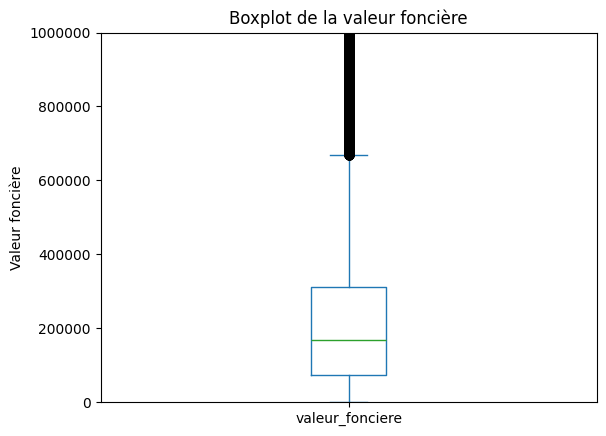

In [4]:
#Boxplot—valeur_fonciere
ax=df["valeur_fonciere"].plot.box()
ax.set_ylim(0,1_000_000)
plt.title("Boxplot de la valeur foncière")
plt.ylabel("Valeur foncière")
plt.ticklabel_format(style='plain',axis='y')
plt.show()

-> L'analyse du boxplot de la variable valeur_foncière met en évidence une forte dispersion des prix immobiliers. La présence d'un grand nombre de valeurs aberrantes au-dessus de la moustache supérieure indique l'existence de biens dont la valeur est exceptionnellement élevée. La distribution est fortement asymétrique à droite, ce qui signifie que la majorité des transactions concerne des biens de valeur modérée tandis qu'un faible nombre de transactions à très forte valeur influence fortement la distribution. Cette observation confirme les résultats obtenus lors de l'analyse descriptive et justifie l'utilisation de méthodes robustes pour l'analyse des données.

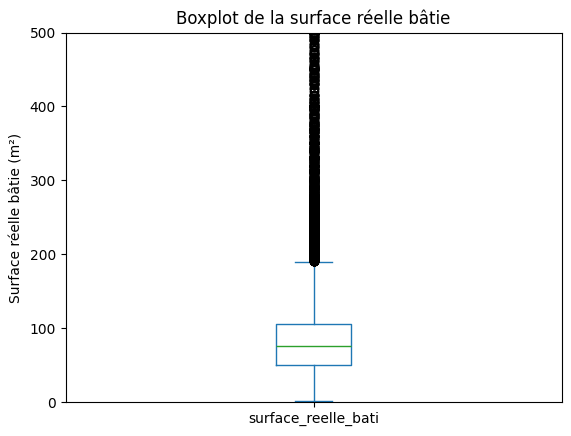

In [5]:
# Boxplot—surface_reelle_bati
ax =df["surface_reelle_bati"].plot.box()
ax.set_ylim(0,500)
plt.title("Boxplot de la surface réelle bâtie")
plt.ylabel("Surface réelle bâtie (m²)")
plt.ticklabel_format(style='plain',axis='y')
plt.show()

-> L'analyse du boxplot de la surface réelle bâtie montre que la majorité des biens immobiliers possède une superficie comprise entre 50 m² et 100 m², avec une médiane située autour de 75 m². La présence d'un grand nombre de valeurs aberrantes au-dessus de la moustache supérieure révèle l'existence de biens de très grande superficie. La distribution est fortement asymétrique à droite, ce qui indique que quelques bâtiments de grande taille influencent fortement la répartition des surfaces. Cette observation confirme l'hétérogénéité des biens immobiliers étudiés.

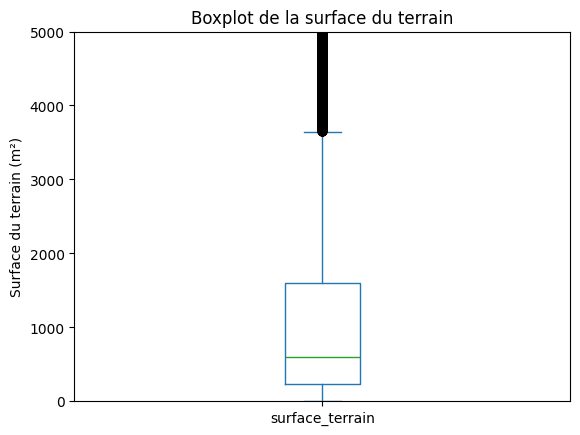

In [6]:
# Boxplot—surface_terrain
ax=df["surface_terrain"].plot.box()
ax.set_ylim(0,5000)
plt.title("Boxplot de la surface du terrain")
plt.ylabel("Surface du terrain (m²)")
plt.ticklabel_format(style='plain',axis='y')
plt.show()

-> L'analyse du boxplot de la surface du terrain révèle une forte dispersion des superficies. La médiane est située autour de 600 m², ce qui signifie que la moitié des terrains possède une surface inférieure à cette valeur. L'étendue importante de la boîte traduit une grande variabilité des surfaces observées. La distribution est fortement asymétrique à droite, indiquant la présence d'un nombre limité de terrains de très grande taille. Cette observation est cohérente avec les résultats de l'analyse descriptive qui ont mis en évidence une forte asymétrie ainsi que des valeurs extrêmes importantes.

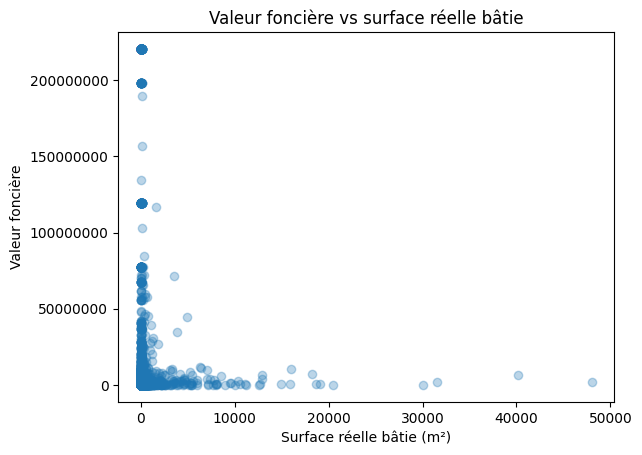

In [7]:
#Scatterplot :valeur_fonciere vs surface_reelle_bati
plt.scatter(df["surface_reelle_bati"],df["valeur_fonciere"],alpha=0.3)
plt.title("Valeur foncière vs surface réelle bâtie")
plt.xlabel("Surface réelle bâtie (m²)")
plt.ylabel("Valeur foncière")
plt.ticklabel_format(style='plain', axis='both')
plt.show()

-> Le nuage de points représentant la valeur foncière en fonction de la surface réelle bâtie met en évidence une relation globalement positive entre les deux variables. En effet, les biens présentant une surface plus importante tendent généralement à avoir une valeur plus élevée. Toutefois, cette relation reste modérée en raison de la forte dispersion des observations. Pour une même superficie, des écarts significatifs de valeur peuvent être observés, ce qui suggère que d'autres facteurs influencent également le prix des biens immobiliers. Le graphique révèle également la présence de nombreuses valeurs aberrantes correspondant à des biens exceptionnels de très grande valeur ou de très grande superficie.

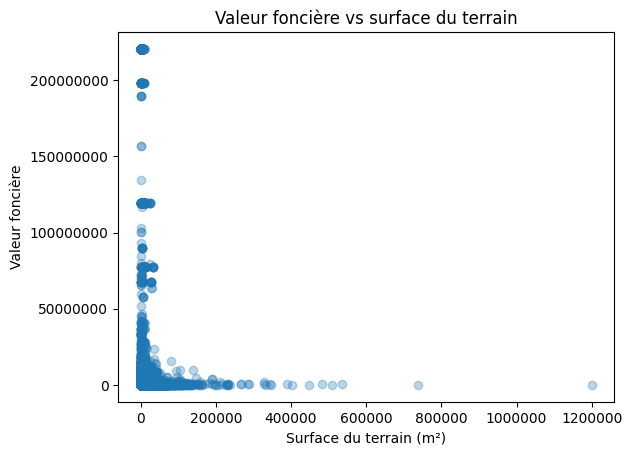

In [8]:
#Scatterplot : valeur_fonciere vs surface_terrain
plt.scatter(df["surface_terrain"],df["valeur_fonciere"],alpha=0.3)
plt.title("Valeur foncière vs surface du terrain")
plt.xlabel("Surface du terrain (m²)")
plt.ylabel("Valeur foncière")
plt.ticklabel_format(style='plain', axis='both')
plt.show()

-> Le nuage de points représentant la valeur foncière en fonction de la surface du terrain montre une relation faible entre les deux variables. Bien que certains biens possédant un terrain plus vaste présentent une valeur élevée, la dispersion importante des observations ne permet pas de dégager une tendance claire. De nombreux biens disposant de terrains similaires présentent des valeurs foncières très différentes, ce qui suggère que d'autres facteurs influencent davantage le prix des biens immobiliers. Le graphique met également en évidence la présence de plusieurs valeurs aberrantes correspondant à des terrains exceptionnellement grands ou à des biens de très forte valeur.

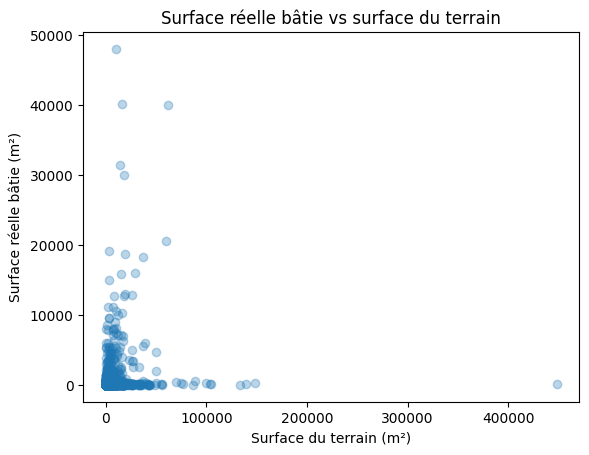

In [9]:
#Scatterplot : surface_reelle_bati vs surface_terrain
plt.scatter(df["surface_terrain"],df["surface_reelle_bati"],alpha=0.3)
plt.title("Surface réelle bâtie vs surface du terrain")
plt.xlabel("Surface du terrain (m²)")
plt.ylabel("Surface réelle bâtie (m²)")
plt.ticklabel_format(style='plain',axis='both')
plt.show()

-> Le nuage de points représentant la surface réelle bâtie en fonction de la surface du terrain met en évidence une relation positive mais relativement faible entre les deux variables. En effet, les biens disposant d'un terrain plus vaste tendent globalement à présenter une surface bâtie plus importante. Toutefois, la forte dispersion des observations montre que la taille du terrain ne détermine pas à elle seule la superficie construite. Le graphique révèle également la présence de plusieurs valeurs aberrantes correspondant à des terrains ou bâtiments de dimensions exceptionnelles. Cette variabilité suggère que d'autres facteurs interviennent dans la relation entre la surface du terrain et la surface bâtie.

                           valeur_fonciere  surface_reelle_bati  \
valeur_fonciere                   1.000000             0.001635   
surface_reelle_bati               0.001635             1.000000   
surface_terrain                   0.007189             0.155175   
nombre_pieces_principales        -0.017596            -0.043820   

                           surface_terrain  nombre_pieces_principales  
valeur_fonciere                   0.007189                  -0.017596  
surface_reelle_bati               0.155175                  -0.043820  
surface_terrain                   1.000000                  -0.039642  
nombre_pieces_principales        -0.039642                   1.000000  


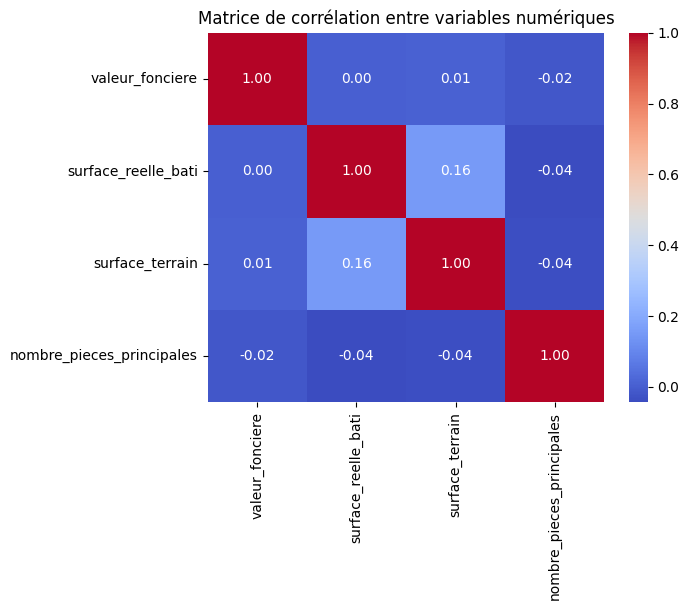

In [10]:
#Matrice de corrélation
df_corr=df[["valeur_fonciere","surface_reelle_bati","surface_terrain","nombre_pieces_principales"]]
corr_matrix=df_corr.corr()
print(corr_matrix)
sns.heatmap(corr_matrix,annot=True,cmap="coolwarm",fmt=".2f")
plt.title("Matrice de corrélation entre variables numériques")
plt.show()

-> La matrice de corrélation met en évidence des corrélations faibles entre la valeur foncière et les variables numériques étudiées. La surface réelle bâtie et la surface du terrain présentent des coefficients proches de zéro avec la valeur foncière, ce qui indique l'absence de relation linéaire significative. La corrélation la plus élevée est observée entre la surface bâtie et la surface du terrain (0,13), mais elle reste faible. Ces résultats suggèrent que la valeur d'un bien immobilier dépend de nombreux autres facteurs non pris en compte dans cette analyse, notamment la localisation, le type de bien ou les caractéristiques spécifiques du marché immobilier. Cette observation justifie l'utilisation de modèles de Machine Learning capables de capturer des relations non linéaires plus complexes.

In [11]:
#Suppression des doublons
print("Nombre de doublons avant :",df.duplicated().sum())
df=df.drop_duplicates()
print("Nombre de doublons après :",df.duplicated().sum())


Nombre de doublons avant : 625
Nombre de doublons après : 0


In [12]:
#Gestion des valeurs manquantes
num_cols=["valeur_fonciere","surface_reelle_bati","surface_terrain","nombre_pieces_principales","longitude","latitude"]
df[num_cols]=df[num_cols].fillna(df[num_cols].median())
categorie_cols=["type_local","nature_mutation","nature_culture","nature_culture_speciale","nom_commune"]
for col in categorie_cols:
    df[col]=df[col].fillna(df[col].mode()[0])

In [13]:
del df_21
del df_22
del df_23

In [14]:
#Correction des incohérences
df=df[df["valeur_fonciere"]>0]
df=df[df["surface_reelle_bati"]>=0]
df=df[df["surface_terrain"]>=0]

Les variables ont été converties vers des types adaptés à leur nature. La variable date_mutation a été transformée au format date afin de permettre les analyses temporelles, tandis que la variable annee a été convertie en entier pour faciliter les traitements statistiques et les regroupements par année.

In [15]:
#Conversion des types
df["date_mutation"]=pd.to_datetime(df["date_mutation"],errors="coerce")
df["annee"]=df["annee"].astype(int)

Afin d'enrichir l'analyse, une variable dérivée représentant le prix au mètre carré a été calculée. Cet indicateur permet de comparer plus efficacement les biens immobiliers indépendamment de leur superficie. Une analyse du prix moyen par année a ensuite été réalisée afin d'étudier l'évolution du marché immobilier entre 2021 et 2023.

In [16]:
#Variable dérivée
df["prix_m2"]=df["valeur_fonciere"]/df["surface_reelle_bati"]
#Prix moyen par année
prix_par_annee=df.groupby("annee")["valeur_fonciere"].mean()
print(prix_par_annee)

annee
2021    1.901555e+06
2022    5.095599e+05
2023    4.445426e+05
Name: valeur_fonciere, dtype: float64


-> L'analyse du prix moyen par année met en évidence une diminution importante de la valeur foncière moyenne entre 2021 et 2022, passant d'environ 808 027 € à 435 445 €. Une légère augmentation est ensuite observée en 2023 avec une valeur moyenne de 457 675 €. Toutefois, la présence d'un nombre important de valeurs extrêmes dans le jeu de données peut influencer fortement ces moyennes. Il est donc pertinent de compléter cette analyse par l'étude de la médiane afin d'obtenir une vision plus représentative de l'évolution du marché immobilier.

In [17]:
#Prix moyen par type de bien
prix_par_type=df.groupby("type_local")["valeur_fonciere"].mean()
print(prix_par_type)

type_local
Appartement                                  3.457861e+06
DÃ©pendance                                  1.039783e+06
Local industriel. commercial ou assimilÃ©    2.010650e+06
Maison                                       5.406399e+05
Name: valeur_fonciere, dtype: float64


-> L'analyse du prix moyen par type de bien révèle des différences importantes entre les catégories immobilières. Les locaux industriels et commerciaux présentent la valeur foncière moyenne la plus élevée (1 985 377 €), suivis des appartements (1 222 751 €). Les dépendances et les maisons affichent des valeurs moyennes plus faibles, respectivement de 529 026 € et 461 371 €. Ces résultats suggèrent que la nature du bien constitue un facteur important dans la détermination de sa valeur. Toutefois, la présence de nombreuses valeurs extrêmes dans le jeu de données peut influencer ces moyennes, ce qui justifie l'analyse complémentaire de la médiane.

In [18]:
# Prix moyen par année ET type de bien
prix_annee_type=df.groupby(["annee", "type_local"])["valeur_fonciere"].mean()
print(prix_annee_type)

annee  type_local                               
2021   Appartement                                  5.451931e+06
       DÃ©pendance                                  1.471217e+06
       Local industriel. commercial ou assimilÃ©    1.975160e+06
       Maison                                       6.729405e+05
2022   Appartement                                  5.832572e+05
       DÃ©pendance                                  4.616371e+05
       Local industriel. commercial ou assimilÃ©    2.303405e+06
       Maison                                       3.086104e+05
2023   Appartement                                  5.354777e+05
       DÃ©pendance                                  3.833376e+05
       Local industriel. commercial ou assimilÃ©    1.854926e+06
       Maison                                       3.325040e+05
Name: valeur_fonciere, dtype: float64


-> L'analyse de la valeur foncière moyenne par année et par type de bien met en évidence des évolutions contrastées selon les catégories. Les appartements, maisons et dépendances enregistrent une baisse importante entre 2021 et 2022 avant une relative stabilisation. À l'inverse, les locaux industriels et commerciaux affichent une progression continue de leur valeur moyenne sur la période étudiée. Ces résultats suggèrent que les dynamiques du marché immobilier varient fortement selon la nature des biens. Toutefois, la présence de valeurs extrêmes peut influencer les moyennes observées et doit être prise en compte dans l'interprétation des résultats.

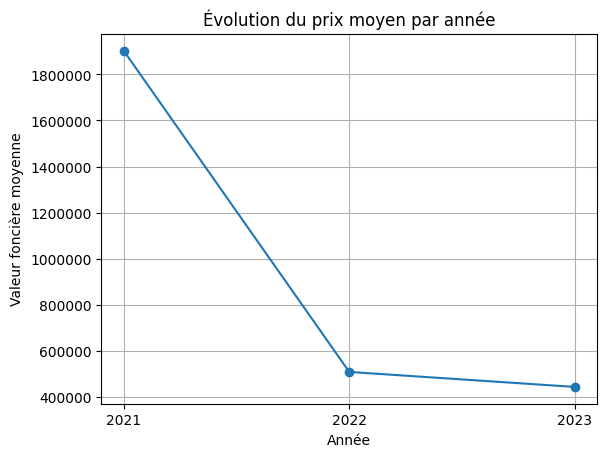

In [19]:
#visualisation évolution du prix moyen par annee
prix_par_annee.plot(marker='o')
plt.title("Évolution du prix moyen par année")
plt.xlabel("Année")
plt.ylabel("Valeur foncière moyenne")
plt.xticks(prix_par_annee.index,prix_par_annee.index.astype(int))
plt.ticklabel_format(style='plain',axis='y')
plt.grid(True)
plt.show()

Bien que ce graphique mette en évidence une baisse importante des prix moyens entre 2021 et 2022, les résultats doivent être interprétés avec prudence en raison de la présence de nombreuses valeurs extrêmes susceptibles d'influencer la moyenne. Une analyse complémentaire basée sur la médiane permettrait d'obtenir une vision plus robuste de l'évolution du marché immobilier.

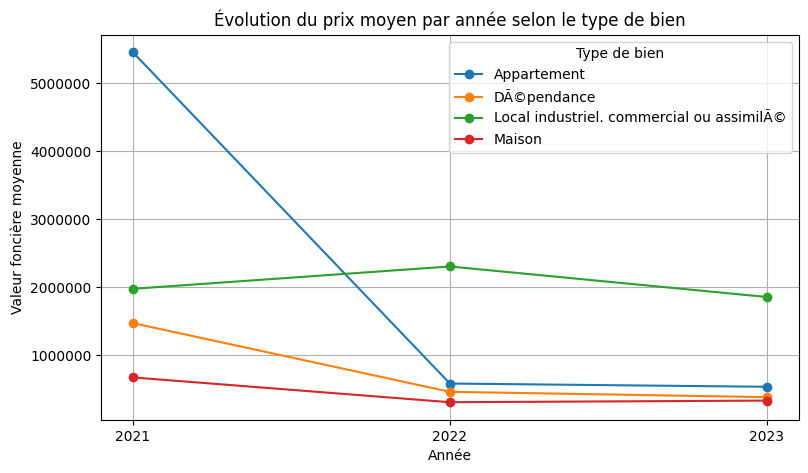

In [20]:
#Évolution du prix moyen par année selon le type de bien
prix_annee_type.unstack().plot(figsize=(9,5),marker='o')
plt.title("Évolution du prix moyen par année selon le type de bien")
plt.xlabel("Année")
plt.ylabel("Valeur foncière moyenne")
plt.xticks(prix_annee_type.index.levels[0],prix_annee_type.index.levels[0].astype(int))
plt.ticklabel_format(style='plain',axis='y')
plt.legend(title="Type de bien")
plt.grid(True)
plt.show()

L'analyse de l'évolution de la valeur foncière moyenne selon le type de bien met en évidence des comportements distincts entre les catégories immobilières. Les appartements, maisons et dépendances enregistrent une baisse significative de leur valeur moyenne entre 2021 et 2022 avant une phase de stabilisation ou de légère reprise en 2023. À l'inverse, les locaux industriels et commerciaux présentent une croissance continue de leur valeur moyenne sur l'ensemble de la période étudiée. Ces résultats montrent que l'évolution du marché immobilier dépend fortement de la nature du bien et que les dynamiques observées ne sont pas uniformes selon les catégories.

In [21]:
#Encodage des variables catégorielles
df=pd.get_dummies(df,columns=["type_local"],prefix="type",dtype=int)

In [22]:
scaler = RobustScaler()

df[[
    "surface_reelle_bati",
    "surface_terrain",
    "nombre_pieces_principales"
]] = scaler.fit_transform(
    df[[
        "surface_reelle_bati",
        "surface_terrain",
        "nombre_pieces_principales"
    ]]
)

In [23]:
print(df.info())

print(df.isna().sum())

print(df.describe())

<class 'pandas.core.frame.DataFrame'>
Index: 99375 entries, 4332218 to 23614
Data columns (total 45 columns):
 #   Column                                          Non-Null Count  Dtype         
---  ------                                          --------------  -----         
 0   id_mutation                                     99375 non-null  object        
 1   date_mutation                                   99375 non-null  datetime64[ns]
 2   numero_disposition                              99375 non-null  int64         
 3   nature_mutation                                 99375 non-null  object        
 4   valeur_fonciere                                 99375 non-null  float64       
 5   adresse_numero                                  64219 non-null  float64       
 6   adresse_suffixe                                 4593 non-null   object        
 7   adresse_nom_voie                                98549 non-null  object        
 8   adresse_code_voie                            

In [25]:
print(df.columns.tolist())

['id_mutation', 'date_mutation', 'numero_disposition', 'nature_mutation', 'valeur_fonciere', 'adresse_numero', 'adresse_suffixe', 'adresse_nom_voie', 'adresse_code_voie', 'code_postal', 'code_commune', 'nom_commune', 'code_departement', 'ancien_code_commune', 'ancien_nom_commune', 'id_parcelle', 'ancien_id_parcelle', 'numero_volume', 'lot1_numero', 'lot1_surface_carrez', 'lot2_numero', 'lot2_surface_carrez', 'lot3_numero', 'lot3_surface_carrez', 'lot4_numero', 'lot4_surface_carrez', 'lot5_numero', 'lot5_surface_carrez', 'nombre_lots', 'code_type_local', 'surface_reelle_bati', 'nombre_pieces_principales', 'code_nature_culture', 'nature_culture', 'code_nature_culture_speciale', 'nature_culture_speciale', 'surface_terrain', 'longitude', 'latitude', 'annee', 'prix_m2', 'type_Appartement', 'type_DÃ©pendance', 'type_Local industriel. commercial ou assimilÃ©', 'type_Maison']


In [26]:
df_ml = df[
[
    "valeur_fonciere",
    "surface_reelle_bati",
    "surface_terrain",
    "nombre_pieces_principales",
    "longitude",
    "latitude",
    "annee",
    "prix_m2",
    "type_Appartement",
    "type_DÃ©pendance",
    "type_Local industriel. commercial ou assimilÃ©",
    "type_Maison"
]
]

In [27]:
print(df_ml.shape)
print(df_ml.head())

(99375, 12)
         valeur_fonciere  surface_reelle_bati  surface_terrain  \
4332218         443000.0                  0.0         0.000000   
2131533         110000.0                 23.0         0.000000   
3724734         258400.0                  0.0         0.154739   
6208092         129000.0                  0.0        -0.063830   
58816           137000.0                 48.0        -0.371373   

         nombre_pieces_principales  longitude   latitude  annee      prix_m2  \
4332218                       -0.5   2.294315  48.833839   2021  5828.947368   
2131533                        2.0   2.741067  48.047474   2021  1111.111111   
3724734                        0.0   5.378399  43.941871   2021  3400.000000   
6208092                        0.0   4.489289  44.041615   2023  1697.368421   
58816                          1.5   3.326261  49.657632   2021  1104.838710   

         type_Appartement  type_DÃ©pendance  \
4332218                 0                 1   
2131533         

Afin de prédire la valeur foncière des biens immobiliers, un modèle Random Forest Regressor a été entraîné sur les données préparées. Les variables utilisées incluent les caractéristiques physiques des biens, leur localisation géographique ainsi que leur type.

Étape 1 : Définir X et y

In [28]:
features = [
    "surface_reelle_bati",
    "surface_terrain",
    "nombre_pieces_principales",
    "longitude",
    "latitude",
    "annee",
    "type_Appartement",
    "type_DÃ©pendance",
    "type_Local industriel. commercial ou assimilÃ©",
    "type_Maison"
]

X = df_ml[features]

y = df_ml["valeur_fonciere"]

Étape 2 : Séparer Train / Test

In [29]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

Étape 3 : Créer le modèle

In [30]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

Étape 4 : Entraîner le modèle

In [31]:
model.fit(X_train, y_train)

RandomForestRegressor(n_jobs=-1, random_state=42)

Étape 5 : Faire les prédictions

In [32]:
y_pred = model.predict(X_test)

Étape 6 : Évaluer les performances

In [33]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import numpy as np

mae = mean_absolute_error(y_test, y_pred)

mse = mean_squared_error(y_test, y_pred)

rmse = np.sqrt(mse)

r2 = r2_score(y_test, y_pred)

print("MAE :", mae)
print("RMSE :", rmse)
print("R² :", r2)

MAE : 935197.9047589295
RMSE : 7376696.297748818
R² : 0.6871451021488912


Le modèle a obtenu un coefficient de détermination (R²) de 0,687, ce qui signifie qu'il est capable d'expliquer environ 68,7 % de la variabilité des prix immobiliers. Les métriques MAE et RMSE indiquent toutefois la présence d'erreurs importantes, principalement dues aux valeurs extrêmes présentes dans le jeu de données.

Étape 7 : Importance des variables

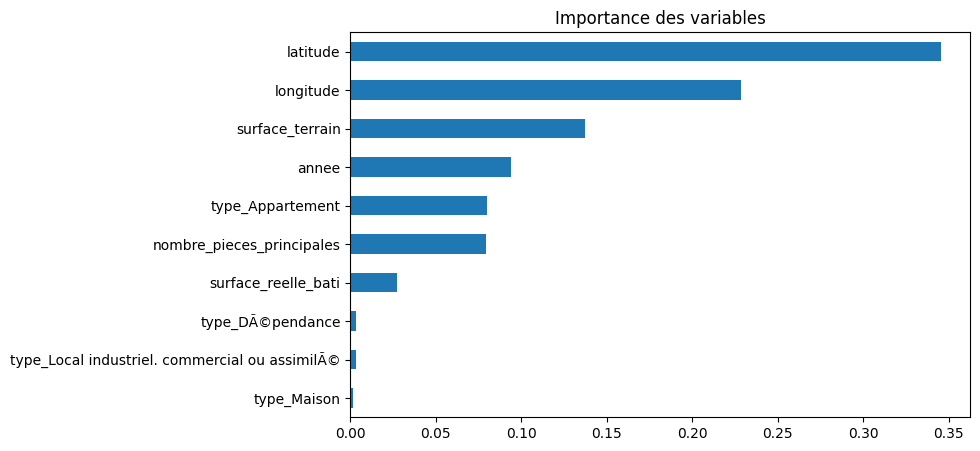

In [34]:
import pandas as pd
import matplotlib.pyplot as plt

importance = pd.Series(
    model.feature_importances_,
    index=features
)

importance.sort_values().plot(
    kind="barh",
    figsize=(8,5)
)

plt.title("Importance des variables")
plt.show()

L'analyse des importances montre que la latitude et la longitude sont les variables les plus influentes dans la prédiction du prix immobilier. Ces résultats confirment que la localisation constitue un facteur déterminant dans l'évaluation des biens immobiliers.